# Stochastic Control Routines for Optimal Execution and Market Making

This notebook implements two small, self-contained stochastic-control examples used in execution and market-making theory:

1. closed-form optimal liquidation with temporary price impact;
2. a symmetric limit-order market-making toy model solved through the Bellman ODE reduction.

The goal is interpretability and numerical transparency, not production trading realism. The notation is introduced explicitly so the notebook can be read as a standalone artifact.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
PROJECT_ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

from stoch_control_trading import (
    LiquidationParams,
    MarketMakingParams,
    inventory_path,
    optimal_rate,
    optimal_quotes,
    simulate_liquidation,
    simulate_market_maker,
    solve_market_making_ode,
)

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

## 1. Closed-form optimal liquidation

The liquidation problem models an agent who starts with inventory `Q_0` and chooses a selling rate `a_t` over a horizon `T`. Positive `a_t` means selling. The state variables are remaining inventory `Q_t`, midprice `S_t`, and cash `X_t`:

$$
\begin{aligned}
dQ_t &= -a_t\,dt, \\
dS_t &= \sigma\,dW_t, \\
\widehat{S}_t &= S_t - \kappa a_t, \\
dX_t &= a_t\widehat{S}_t\,dt
     = a_t(S_t-\kappa a_t)\,dt.
\end{aligned}
$$

The objective is terminal cash plus terminal mark-to-market value, with a quadratic penalty for unsold inventory:

$$
\mathbb{E}\left[
X_T
+ Q_T S_T
- \theta Q_T^2
\right].
$$

Equivalently, substituting the cash dynamics gives the expected sale-proceeds form with the integral of `a_t(S_t-kappa*a_t)`. Here `kappa` controls temporary price impact, `theta` controls the cost of ending with inventory, and `sigma` controls simulated midprice noise. In this simplified risk-neutral formulation, `sigma` affects simulated terminal wealth but not the deterministic closed-form selling policy.

The closed-form policy is

$$
\begin{aligned}
\gamma(t) &= -\left(\frac{1}{\theta} + \frac{T-t}{\kappa}\right)^{-1}, \\
a^*(t,q) &= -\frac{\gamma(t)}{\kappa}q.
\end{aligned}
$$

The policy trades faster when the terminal inventory penalty is higher and trades more slowly when temporary impact is higher.

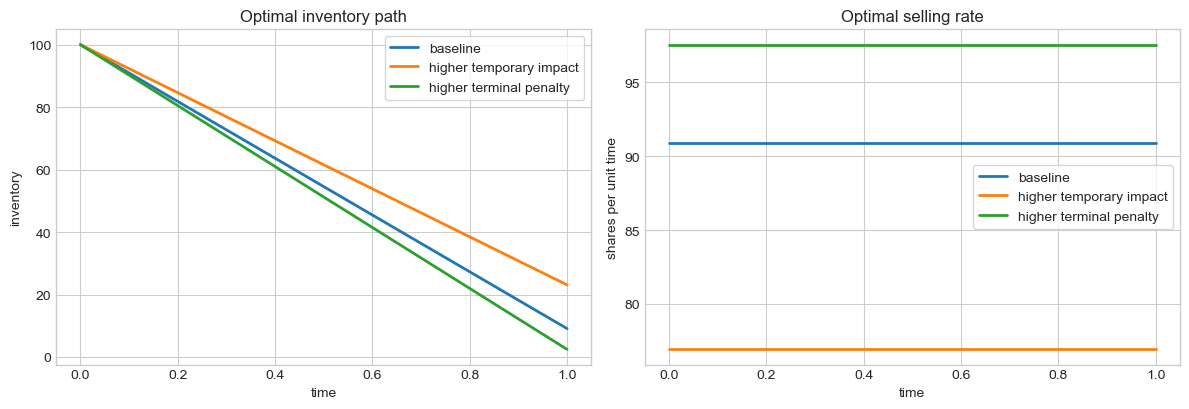

In [2]:
scenarios = [
    ("baseline", LiquidationParams(T=1.0, q0=100.0, s0=100.0, sigma=0.5, kappa=1.0, terminal_penalty=10.0)),
    ("higher temporary impact", LiquidationParams(T=1.0, q0=100.0, s0=100.0, sigma=0.5, kappa=3.0, terminal_penalty=10.0)),
    ("higher terminal penalty", LiquidationParams(T=1.0, q0=100.0, s0=100.0, sigma=0.5, kappa=1.0, terminal_penalty=40.0)),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for label, params in scenarios:
    times = np.linspace(0.0, params.T, 300)
    q = inventory_path(times, params)
    rate = optimal_rate(times, q, params)
    axes[0].plot(times, q, label=label, linewidth=2)
    axes[1].plot(times, rate, label=label, linewidth=2)

axes[0].set_title("Optimal inventory path")
axes[0].set_xlabel("time")
axes[0].set_ylabel("inventory")
axes[1].set_title("Optimal selling rate")
axes[1].set_xlabel("time")
axes[1].set_ylabel("shares per unit time")

for ax in axes:
    ax.legend(frameon=True)

fig.tight_layout()
fig.savefig(FIG_DIR / "liquidation_inventory_paths.png", dpi=160)
plt.show()

In [3]:
liq_params = scenarios[0][1]
liq_sim = simulate_liquidation(liq_params, n_steps=500, n_paths=500, seed=42)

liq_summary = pd.Series(liq_sim["terminal_value"]).describe()[["mean", "std", "min", "max"]]
display(liq_summary.to_frame("terminal value").round(3))

,terminal value
mean,908.070
std,30.751
min,811.573
max,988.002


## 2. Symmetric limit-order market making

The market-making problem models a dealer with midprice `S_t`, cash `X_t`, and inventory `Q_t`. The controls are the bid and ask distances from the midprice: `delta_b` and `delta_a`. A bid fill buys `Delta` units at `S_t-delta_b`; an ask fill sells `Delta` units at `S_t+delta_a`.

Fills are modeled as controlled Poisson arrivals. Quote distances affect fill probabilities through exponentially decaying intensities:

$$
\lambda \exp(-\kappa \delta_b),
\qquad
\lambda \exp(-\kappa \delta_a).
$$

Here `lambda` is the baseline arrival intensity and `kappa` controls how quickly fill intensity falls as quotes move away from the midprice. This captures the basic spread/fill trade-off: quoting closer fills more often, while quoting wider earns more spread conditional on a fill.

The continuous-time state dynamics are

$$
\begin{aligned}
dS_t &= \sigma\,dW_t, \\
dQ_t &= \Delta\,dN_t^b - \Delta\,dN_t^a, \\
dX_t
&= -\Delta(S_t-\delta_b)\,dN_t^b
   + \Delta(S_t+\delta_a)\,dN_t^a.
\end{aligned}
$$

The signs are deliberate: bid fills increase inventory and reduce cash, while ask fills reduce inventory and increase cash.

The objective is terminal marked-to-market wealth, penalized by terminal and running inventory exposure:

$$
\mathbb{E}\left[
X_T + Q_T S_T
- \alpha Q_T^2
- \int_0^T \phi Q_t^2\,dt
\right].
$$

The parameter `alpha` penalizes terminal inventory and `phi` penalizes inventory held during the horizon. The terminal condition is

$$
v(T,S,x,q)=x+Sq-\alpha q^2.
$$

The full Bellman equation is stated in `docs/model_specification.md`. The notebook uses the standard separable ansatz

$$
v(t,S,x,q) = x + Sq + \theta(t,q).
$$

This separates cash and mark-to-market inventory value from the remaining inventory-control value `theta(t,q)`. Since this ansatz is linear in `S`, the midprice-volatility term drops out of the quote policy, though volatility still affects simulated terminal marked-to-market values.

The jump differences simplify to

$$
\begin{aligned}
v(t,S,x-\Delta(S-\delta_b),q+\Delta)-v(t,S,x,q)
&= \Delta\delta_b+\theta(t,q+\Delta)-\theta(t,q), \\
v(t,S,x+\Delta(S+\delta_a),q-\Delta)-v(t,S,x,q)
&= \Delta\delta_a+\theta(t,q-\Delta)-\theta(t,q).
\end{aligned}
$$

In the interior-positive quote regime, the first-order conditions give

$$
\begin{aligned}
\delta_{b}^{*}(t,q)
&= \frac{1}{\kappa}
   - \frac{\theta(t,q+\Delta)-\theta(t,q)}{\Delta}, \\
\delta_{a}^{*}(t,q)
&= \frac{1}{\kappa}
   - \frac{\theta(t,q-\Delta)-\theta(t,q)}{\Delta}.
\end{aligned}
$$

Boundary quotes that would move inventory outside the grid are suppressed. The code also checks that all finite quote distances remain positive for the chosen parameters.

After the transform

$$
\theta(t,q)=\frac{\Delta}{\kappa}\log W(t,q),
$$

the symmetric finite-grid Bellman system is linear:

$$
\begin{aligned}
W'(t) + A W(t) &= 0, \\
W(t) &= \exp\left((T-t)A\right)W(T).
\end{aligned}
$$

The matrix exponential solution below uses

$$
\begin{aligned}
W(T,q) &= \exp\left(-\frac{\kappa}{\Delta}\alpha q^2\right), \\
A_{q,q} &= -\frac{\kappa}{\Delta}\phi q^2, \\
A_{q,q+\Delta} &= \lambda e^{-1}, \\
A_{q,q-\Delta} &= \lambda e^{-1}.
\end{aligned}
$$

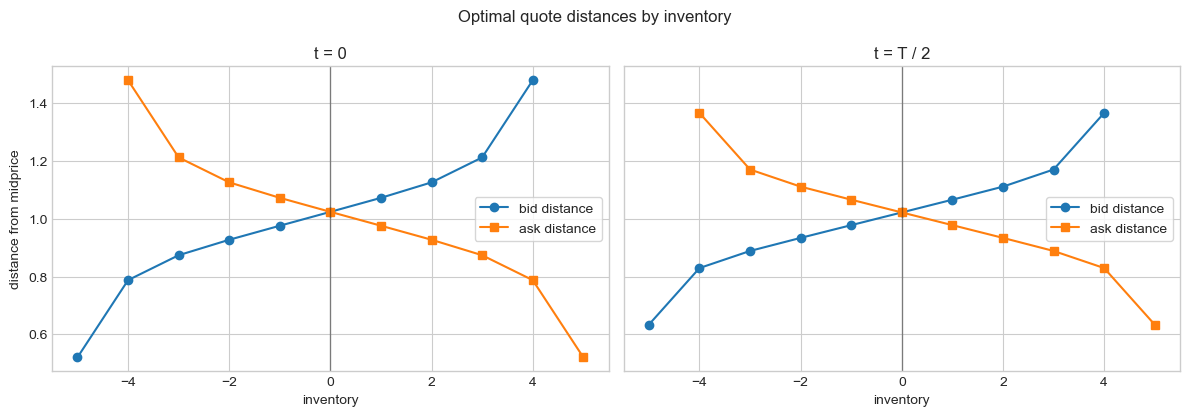

In [4]:
mm_params = MarketMakingParams(
    T=1.0,
    Delta=1.0,
    q_min=-5.0,
    q_max=5.0,
    lam=1.5,
    kappa=1.0,
    alpha=0.02,
    phi=0.005,
    sigma=0.5,
    s0=100.0,
    q0=0.0,
    x0=0.0,
)

mm_times = np.linspace(0.0, mm_params.T, 101)
mm_solution = solve_market_making_ode(mm_params, mm_times)
quotes = optimal_quotes(mm_solution["theta"], mm_params)

finite_bid = quotes["bid"][np.isfinite(quotes["bid"])]
finite_ask = quotes["ask"][np.isfinite(quotes["ask"])]
assert finite_bid.min() > 0.0
assert finite_ask.min() > 0.0

q_grid = mm_solution["q_grid"]
half_idx = int(np.argmin(np.abs(mm_solution["times"] - mm_params.T / 2)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)

for ax, idx, title in [
    (axes[0], 0, "t = 0"),
    (axes[1], half_idx, "t = T / 2"),
]:
    ax.plot(q_grid[:-1], quotes["bid"][idx, :-1], marker="o", label="bid distance")
    ax.plot(q_grid[1:], quotes["ask"][idx, 1:], marker="s", label="ask distance")
    ax.set_title(title)
    ax.set_xlabel("inventory")
    ax.axvline(0.0, color="black", linewidth=1, alpha=0.4)
    ax.legend(frameon=True)

axes[0].set_ylabel("distance from midprice")
fig.suptitle("Optimal quote distances by inventory")
fig.tight_layout()
fig.savefig(FIG_DIR / "market_making_quotes.png", dpi=160)
plt.show()

Inventory skews the quotes: long inventory makes the ask more aggressive and the bid less aggressive; short inventory does the opposite. Boundary quotes are suppressed to keep the inventory inside the grid.

The simulation below uses a longer, more active fill setting (`T=2`, `lambda=3`) only to make inventory jumps easier to see. The quote plot above keeps the baseline Bellman/ODE parameters. Over a time step `dt`, the continuous-time Poisson fills are approximated by a first-event discretization:

$$
\begin{aligned}
\lambda_b &= \lambda e^{-\kappa\delta_b}, \\
\lambda_a &= \lambda e^{-\kappa\delta_a}, \\
\Lambda &= \lambda_b+\lambda_a, \\
p_{\mathrm{fill}} &= 1-\exp[-\Lambda dt].
\end{aligned}
$$

Conditional on a fill, the side is sampled by relative intensity:

$$
\mathbb{P}(\mathrm{bid}\mid\mathrm{fill})=\frac{\lambda_b}{\Lambda},
\qquad
\mathbb{P}(\mathrm{ask}\mid\mathrm{fill})=\frac{\lambda_a}{\Lambda}.
$$

The histogram compares terminal marked-to-market value with the objective-adjusted value after subtracting the discretized running inventory penalty controlled by `phi`.

,terminal_inventory,terminal_value,running_inventory_penalty,objective_value,terminal_cash
count,250.000,250.000,250.000,250.000,250.000
mean,0.056,4.699,0.018,4.681,-0.891
std,1.847,2.443,0.021,2.437,184.602
min,-5.000,0.000,0.000,0.000,-394.547
25%,-1.000,2.896,0.005,2.883,-98.127
50%,0.000,4.458,0.010,4.441,3.590
75%,1.000,6.100,0.024,6.078,107.027
max,4.000,11.301,0.116,11.254,508.589


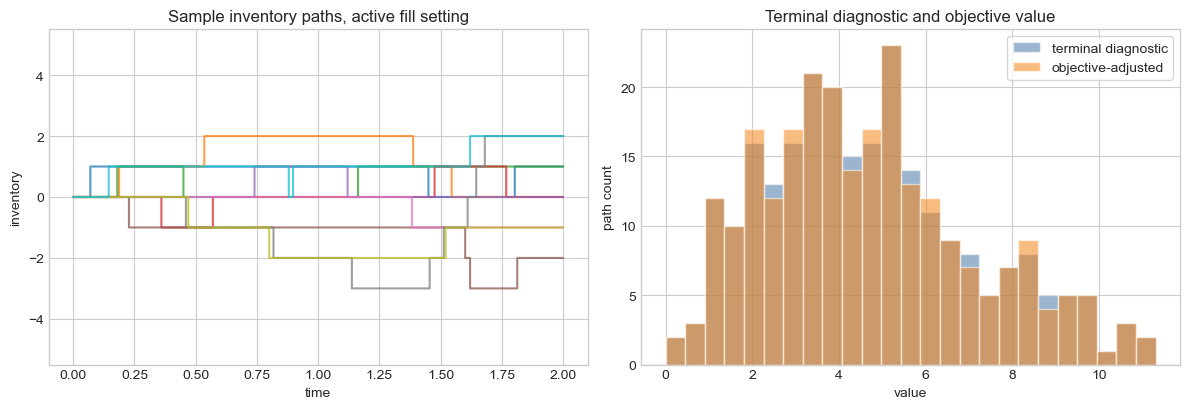

In [5]:
mm_sim_params = MarketMakingParams(
    T=2.0,
    Delta=mm_params.Delta,
    q_min=mm_params.q_min,
    q_max=mm_params.q_max,
    lam=3.0,
    kappa=mm_params.kappa,
    alpha=mm_params.alpha,
    phi=mm_params.phi,
    sigma=mm_params.sigma,
    s0=mm_params.s0,
    q0=mm_params.q0,
    x0=mm_params.x0,
)
mm_sim = simulate_market_maker(mm_sim_params, n_steps=800, n_paths=250, seed=13)

terminal = pd.DataFrame(
    {
        "terminal_inventory": mm_sim["inventory"][:, -1],
        "terminal_value": mm_sim["terminal_value"],
        "running_inventory_penalty": mm_sim["running_inventory_penalty"],
        "objective_value": mm_sim["objective_value"],
        "terminal_cash": mm_sim["cash"][:, -1],
    }
)
display(terminal.describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for path in range(10):
    axes[0].step(mm_sim["times"], mm_sim["inventory"][path], where="post", alpha=0.75)

axes[0].set_title("Sample inventory paths, active fill setting")
axes[0].set_xlabel("time")
axes[0].set_ylabel("inventory")
axes[0].set_ylim(mm_sim_params.q_min - 0.5, mm_sim_params.q_max + 0.5)

value_min = min(terminal["terminal_value"].min(), terminal["objective_value"].min())
value_max = max(terminal["terminal_value"].max(), terminal["objective_value"].max())
bins = np.linspace(value_min, value_max, 26)
axes[1].hist(
    terminal["terminal_value"],
    bins=bins,
    color="#4C78A8",
    edgecolor="white",
    alpha=0.55,
    label="terminal diagnostic",
)
axes[1].hist(
    terminal["objective_value"],
    bins=bins,
    color="#F58518",
    edgecolor="white",
    alpha=0.55,
    label="objective-adjusted",
)
axes[1].set_title("Terminal diagnostic and objective value")
axes[1].set_xlabel("value")
axes[1].set_ylabel("path count")
axes[1].legend(frameon=True)

fig.tight_layout()
fig.savefig(FIG_DIR / "market_making_simulation_summary.png", dpi=160)
plt.show()

### Bellman Value Sanity Check

The solved Bellman equation gives the model value at the initial state as

$$
v(0,S_0,x_0,q_0)=x_0+S_0q_0+\theta(0,q_0).
$$

The simulator is a first-event discretization, so this is not an exact equality test. The useful check is that the objective-adjusted Monte Carlo payoff under the computed policy is statistically compatible with the solved Bellman value, allowing for Monte Carlo error and discretization error.

In [6]:
sanity_params = MarketMakingParams()
sanity_solution = solve_market_making_ode(sanity_params, np.array([0.0]))
sanity_q_grid = sanity_solution["q_grid"]
sanity_q0_index = int(np.flatnonzero(np.isclose(sanity_q_grid, sanity_params.q0))[0])
bellman_value = (
    sanity_params.x0
    + sanity_params.s0 * sanity_params.q0
    + sanity_solution["theta"][0, sanity_q0_index]
)

sanity_sim = simulate_market_maker(sanity_params, n_steps=300, n_paths=400, seed=2024)
sanity_objective = sanity_sim["objective_value"]
sanity_mean = sanity_objective.mean()
sanity_se = sanity_objective.std(ddof=1) / np.sqrt(sanity_objective.size)
sanity_interval = (sanity_mean - 4.0 * sanity_se, sanity_mean + 4.0 * sanity_se)

assert sanity_interval[0] <= bellman_value <= sanity_interval[1]

pd.DataFrame(
    {
        "bellman_value": [bellman_value],
        "mc_objective_mean": [sanity_mean],
        "mc_standard_error": [sanity_se],
        "four_se_lower": [sanity_interval[0]],
        "four_se_upper": [sanity_interval[1]],
    }
).round(3)

,bellman_value,mc_objective_mean,mc_standard_error,four_se_lower,four_se_upper
0,1.08,1.076,0.054,0.859,1.293


## Limitations

- Synthetic model only; no exchange-data calibration.
- No tick size, queue priority, latency, fees, adverse selection, or hidden liquidity.
- Symmetric arrival rates and symmetric exponential decay in quote distance.
- Simulation uses a first-event time discretization of continuous-time Poisson fills.
- This is a stochastic-control illustration, not a deployable trading strategy.